이 데이터셋을 통해서, 고객들에게 자동차보험 크로스셀을 제안하려고 합니다.  
이진 분류로 예측할건데, 어떤 고객이 과연 자동차 보험을 가입할 가능성이 높을까요?

# Data Load

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#지수표기법 X
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [ ]:
# Load the dataset
train = pd.read_csv('D:/train.csv')
test = pd.read_csv('D:/test.csv')
sample_submission = pd.read_csv('D:/sample_submission.csv')

# Variable Description

| Feature Name | Type | Description |
|---|---|---|
| id | Continuous | 고객 고유 식별자 |
| Age | Continuous | 고객의 나이 |
| Gender | Dichotomous | 고객의 성별 |
| Driving_License | Dichotomous | 0: 운전면허 없음, 1: 운전면허 있음 |
| Region_Code | Nominal | 고객 지역의 고유 코드 |
| Previously_Insured | Dichotomous | 0: 차량 보험 미가입, 1: 차량 보험 가입 |
| Vehicle_Age | Nominal | 차량 연식 |
| Vehicle_Damage | Dichotomous | 0: 과거 차량 사고 없음, 1: 과거 차량 사고 있음 |
| Annual_Premium | Continuous | 고객이 연간 납부해야 하는 보험료 |
| Policy_Sales_Channel | Nominal | 고객 접촉 채널의 익명화된 코드 (영업사원, 이메일, 전화, 대면 등) |
| Vintage | Continuous | 고객이 회사와 거래한 기간 (일 단위) |
| **Response** (Target) | Dichotomous | 1: 고객 관심 있음, 0: 고객 관심 없음 |

# Data Wrangling

In [9]:
train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0


In [11]:
train.shape

(11504798, 12)

In [15]:
train.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000,11504798.000
mean,5752398.500,38.384,0.998,26.419,0.463,30461.370,112.425,163.898,0.123
std,3321149.255,14.993,0.044,12.992,0.499,16454.745,54.036,79.980,0.328
min,0.000,20.000,0.000,0.000,0.000,2630.000,1.000,10.000,0.000
25%,2876199.250,24.000,1.000,15.000,0.000,25277.000,29.000,99.000,0.000
50%,5752398.500,36.000,1.000,28.000,0.000,31824.000,151.000,166.000,0.000
75%,8628597.750,49.000,1.000,35.000,1.000,39451.000,152.000,232.000,0.000
max,11504797.000,85.000,1.000,52.000,1.000,540165.000,163.000,299.000,1.000


**Insight**

- Annual_premium 변수에서 연 5천 만원을 내는 사람있음.

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11504798 entries, 0 to 11504797
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Gender                object 
 2   Age                   int64  
 3   Driving_License       int64  
 4   Region_Code           float64
 5   Previously_Insured    int64  
 6   Vehicle_Age           object 
 7   Vehicle_Damage        object 
 8   Annual_Premium        float64
 9   Policy_Sales_Channel  float64
 10  Vintage               int64  
 11  Response              int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 1.0+ GB


In [21]:
# 일단 먼저 수치형, 범주형 변수 분리
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('id')  # id 컬럼 제외
cat_cols = train.select_dtypes(include='object').columns.tolist()

# 데이터 탐색해보기

In [22]:
# num_cols
num_cols

['Age',
 'Driving_License',
 'Region_Code',
 'Previously_Insured',
 'Annual_Premium',
 'Policy_Sales_Channel',
 'Vintage',
 'Response']

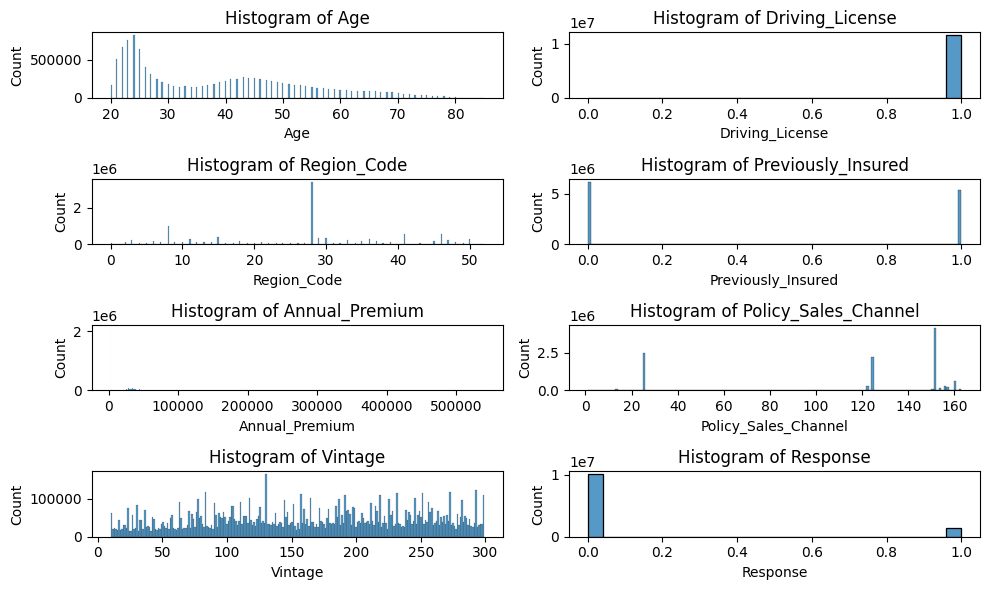

In [33]:
# 수치형 변수 히스토그램
plt.figure(figsize=(10, 6))
i = 0
for col in num_cols:
    i += 1
    plt.subplot(4, 2, i)
    sns.histplot(train[col])
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


In [37]:
(train['Driving_License'].value_counts() / len(train)) * 100

Driving_License
1   99.802
0    0.198
Name: count, dtype: float64

**Insight**

- 20~30대가 많이 분포되어있음 
- 해당 데이터셋에는 99.8%가 운전면허증을 가지고 있음. 운전면허증이 없는 사람들은 자동차 보험 크로스셀에 관심 없지 않을까? 또는 추후에 곧 차량 구매하려고 하는 사람이 있다면 관심있지 않을까?
- previously_insured 차량 보험 미가입과 차량 보험 가입자의 비율은 비슷함
- Annual_premium에 이상값이 있음 (전처리 필요)
- Response 변수에 자동차 보험에 관심없는 비율이 훨씬 많음

In [38]:
# 연령별 연 보혐료 분포를 확인해서, 고객이 관심이 있는지 확인
# 가설 - 나이가 많을수록 연 보험료가 높기에, 구매력이 있기 때문에,
# 자동차 보험 가입하는 것에 어느정도 관심이 있을것이다.

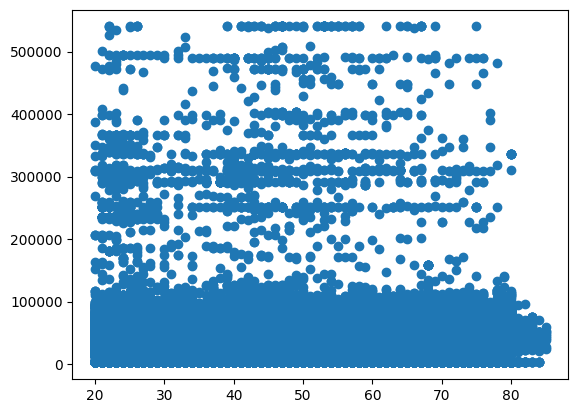

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(train['Age'], train['Annual_Premium'])

**Insight**
- 연령이 높을수록, 연 보험료가 높을 것이라 생각했는데, 아니다. 상관관계가 없어보인다.

In [41]:
# 운전면허가 있는 사람과 없는 사람별로 자동차 보험 관심있는지 확인
plt.figure(figsize=(8,6))
pd.crosstab(train['Driving_License'], train['Response'], normalize='index')

Response,0,1
Driving_License,,
0,0.945,0.055
1,0.877,0.123


<Figure size 800x600 with 0 Axes>

**Insight**

- 운전면허가 없는데, 관심있다고 한 비율은 약 5%
- 운전면허가 있는데, 관심있다고 한 비율은 약 12%
> 이 두 가지 범주에 속하는 고객(총 17%)이 주 타겟이 되겠다. 그들에게 집중적으로 설득을 진행한다.

- 운전면허가 있는데, 관심 없다고 한 비율은 약 87%
> 건강보험은 본 회사걸로 들고 있지만, 본 회사의 자동차 보험에는 관심이 없는 경우가 되겠다. 타 회사의 자동차 보험을 들고 있는 경우가 있을 것이다.

그렇다면 추가로, 관심없다고 한 비율 분들을 대상으로, 실제로 기존에 차량보험에 가입되어있는지, 아님 본 회사의 자동차 보험이 필요하지 않은건지 봐야겠다.


In [46]:
# 차량 보험에 가입되어 있는 사람과 안되어있는 사람의 관심도

plt.figure(figsize=(8, 6))
pd.crosstab(train['Previously_Insured'], train['Response'], normalize='index').round(4)


Response,0,1
Previously_Insured,,
0,0.771,0.229
1,0.999,0.001


<Figure size 800x600 with 0 Axes>

**Insight**
- 차량보험이 있으니 관심이 없다. 1%의 관심 고객은 뭘까?
> 한국 기준으로, 손해보험의 원칙인 '두 개 이상의 자동차보험은 가입이 불가능하다' 그럼 1%는 오입력일 것이고, 미국 기준으로, 중복 가입이 합법이나 권장하지 않는다고 한다. 이들은 우리 상품을 소개할 고객에서 제외한다.

- 차량보험이 없는데, 관심이 있는 사람의 비율이 약 23%다. 이후에 차량을 운전할 예정일 사람일 수 있따.

우리 회사의 자동차 보험을 판매하기 위해선, 일단 저 1%의 고객은 제외한다.

In [62]:
# 차량 사고를 낸 경험이 있는 사람이라면, 자동차 보험에 관심이 있지 않을까?

plt.figure(figsize=(8, 6))
pd.crosstab([train['Driving_License'], train['Previously_Insured'], train['Vehicle_Damage']], 
            train['Response']).style.background_gradient(cmap='coolwarm')


<Figure size 800x600 with 0 Axes>

**Insight**
- 운전면허 있고, 자동차 보험은 없고, 이전에 사고를 낸 경험이 있는 사람이 큰 관심을 가진다. (1387977명)

- 운전면허 있고, 자동차 보험은 없고, 이전에 사고를 낸 경험이 없는 사람이 큰 관심을 가진다. (22432명)

- 운전면허 없고, 자동차 보험도 가입이 되어있지않고, 이전에 사고를 낸 경험이 있는 사람이 관심을 가진다. (1240명)